In [7]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [8]:
results_dir = Path("/root/CS5782-LoRA-Final-Project/results")  
summary_files = sorted(results_dir.glob("*/summary.json"))

print(f"Found {len(summary_files)} summary files")
for p in summary_files:
    print(" -", p)

rows = []
for p in summary_files:
    with open(p, "r", encoding="utf-8") as f:
        d = json.load(f)

    eval_metrics = d.get("eval_metrics", {})
    row = {
        "task": d.get("task"),
        "method": d.get("method"),
        "trainable_parameters": d.get("trainable_parameters"),
        "total_parameters": d.get("total_parameters"),
        "runtime_seconds": d.get("runtime_seconds"),
        "path": str(p),
    }

    for k, v in eval_metrics.items():
        row[k] = v

    # LoRA 相关配置（只有 LoRA 有值）
    row["lora_rank"] = d.get("lora_rank")
    row["lora_alpha"] = d.get("lora_alpha")
    row["lora_targets"] = ",".join(d.get("lora_targets", [])) if d.get("lora_targets") else None

    rows.append(row)

df = pd.DataFrame(rows)

df["trainable_ratio"] = df["trainable_parameters"] / df["total_parameters"]
df["runtime_minutes"] = df["runtime_seconds"] / 60.0

method_order = ["full", "frozen", "lora"]
task_order = ["mnli", "mrpc", "qnli", "qqp", "sst2", "cola"]
df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)
df["task"] = pd.Categorical(df["task"], categories=task_order, ordered=True)
df = df.sort_values(["task", "method"]).reset_index(drop=True)

df

Found 18 summary files
 - /root/CS5782-LoRA-Final-Project/results/cola_frozen/summary.json
 - /root/CS5782-LoRA-Final-Project/results/cola_full/summary.json
 - /root/CS5782-LoRA-Final-Project/results/cola_lora/summary.json
 - /root/CS5782-LoRA-Final-Project/results/mnli_frozen/summary.json
 - /root/CS5782-LoRA-Final-Project/results/mnli_full/summary.json
 - /root/CS5782-LoRA-Final-Project/results/mnli_lora/summary.json
 - /root/CS5782-LoRA-Final-Project/results/mrpc_frozen/summary.json
 - /root/CS5782-LoRA-Final-Project/results/mrpc_full/summary.json
 - /root/CS5782-LoRA-Final-Project/results/mrpc_lora/summary.json
 - /root/CS5782-LoRA-Final-Project/results/qnli_frozen/summary.json
 - /root/CS5782-LoRA-Final-Project/results/qnli_full/summary.json
 - /root/CS5782-LoRA-Final-Project/results/qnli_lora/summary.json
 - /root/CS5782-LoRA-Final-Project/results/qqp_frozen/summary.json
 - /root/CS5782-LoRA-Final-Project/results/qqp_full/summary.json
 - /root/CS5782-LoRA-Final-Project/results/qq

,task,method,trainable_parameters,total_parameters,runtime_seconds,path,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_matthews_correlation,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,lora_rank,lora_alpha,lora_targets,trainable_ratio,runtime_minutes
0,mnli,full,124647939,124647939,22768.400223,/root/CS5782-LoRA-Final-Project/results/mnli_f...,0.466089,0.859806,0.859415,0.859571,0.859222,NaN,29.5417,332.243,5.213,3.0,8,16,"query,value",1.000000,379.473337
1,mnli,frozen,592899,124647939,2405.835055,/root/CS5782-LoRA-Final-Project/results/mnli_f...,0.997671,0.533367,0.538184,0.534311,0.533737,NaN,68.6565,142.958,2.243,3.0,8,16,"query,value",0.004757,40.097251
2,mnli,lora,887811,124942851,19447.589051,/root/CS5782-LoRA-Final-Project/results/mnli_l...,0.391826,0.849516,0.848365,0.848572,0.848441,NaN,45.1584,217.346,3.410,3.0,8,16,"query,value",0.007106,324.126484
3,mrpc,full,124647170,124647170,413.311720,/root/CS5782-LoRA-Final-Project/results/mrpc_f...,0.541590,0.872549,0.882155,0.939068,0.909722,NaN,4.1430,98.479,1.690,3.0,8,16,"query,value",1.000000,6.888529
4,mrpc,frozen,592130,124647170,48.583437,/root/CS5782-LoRA-Final-Project/results/mrpc_f...,0.617307,0.683824,0.683824,1.000000,0.812227,NaN,1.1570,352.633,6.050,3.0,8,16,"query,value",0.004750,0.809724
5,mrpc,lora,887042,124942082,7995.755856,/root/CS5782-LoRA-Final-Project/results/mrpc_l...,1.002249,0.877451,NaN,NaN,0.910394,NaN,11.0958,36.771,0.631,30.0,8,16,"query,value",0.007100,133.262598
6,qnli,full,124647170,124647170,9353.297200,/root/CS5782-LoRA-Final-Project/results/qnli_f...,0.283963,0.910855,0.913455,0.909815,0.911631,NaN,38.7938,140.821,2.217,3.0,8,16,"query,value",1.000000,155.888287
7,qnli,frozen,592130,124647170,2124.009238,/root/CS5782-LoRA-Final-Project/results/qnli_f...,0.648796,0.663006,0.675841,0.640348,0.657616,NaN,28.4065,192.315,3.027,3.0,8,16,"query,value",0.004750,35.400154
8,qnli,lora,887042,124942082,2227.169584,/root/CS5782-LoRA-Final-Project/results/qnli_l...,0.242442,0.904814,0.913621,0.896414,0.904936,NaN,48.6605,112.268,1.767,3.0,8,16,"query,value",0.007100,37.119493
9,qqp,full,124647170,124647170,20383.742682,/root/CS5782-LoRA-Final-Project/results/qqp_fu...,0.416854,0.804106,0.725858,0.751898,0.738648,NaN,57.9518,697.649,10.906,3.0,8,16,"query,value",1.000000,339.729045


In [9]:
df.to_csv('/root/CS5782-LoRA-Final-Project/outputs/compare_results.csv', index=False)

In [10]:
metrics_to_compare = ["eval_accuracy", "eval_f1", "eval_loss", "runtime_minutes", "trainable_ratio"]

for metric in metrics_to_compare:
    pivot = df.pivot(index="task", columns="method", values=metric)
    print(f"\n===== {metric} =====")
    display(pivot)

wide = df.set_index(["task", "method"])[metrics_to_compare].unstack("method")
print("\nCombined wide table:")
display(wide)


===== eval_accuracy =====


method,full,frozen,lora
task,,,
mnli,0.859806,0.533367,0.849516
mrpc,0.872549,0.683824,0.877451
qnli,0.910855,0.663006,0.904814
qqp,0.804106,0.751447,0.873609
sst2,0.919725,0.806193,0.934633
cola,0.826462,0.691275,0.793864



===== eval_f1 =====


method,full,frozen,lora
task,,,
mnli,0.859222,0.533737,0.848441
mrpc,0.909722,0.812227,0.910394
qnli,0.911631,0.657616,0.904936
qqp,0.738648,0.636919,0.834660
sst2,0.921875,0.822665,0.936170
cola,0.882848,0.817460,0.863492



===== eval_loss =====


...

method,full,frozen,lora
task,,,
mnli,379.473337,40.097251,324.126484
mrpc,6.888529,0.809724,133.262598
qnli,155.888287,35.400154,37.119493
qqp,339.729045,110.924553,239.020499
sst2,105.553827,6.407611,41.224486
cola,5.984266,3.607331,5.035898



===== trainable_ratio =====


method,full,frozen,lora
task,,,
mnli,1.0,0.004757,0.007106
mrpc,1.0,0.004750,0.007100
qnli,1.0,0.004750,0.007100
qqp,1.0,0.004750,0.007100
sst2,1.0,0.004750,0.007100
cola,1.0,0.004750,0.007100



Combined wide table:


eval_accuracy                       eval_f1                     eval_loss                     runtime_minutes                         trainable_ratio                    
method          full    frozen      lora      full    frozen      lora      full    frozen      lora            full      frozen        lora            full    frozen      lora
task                                                                                                                                                                            
mnli        0.859806  0.533367  0.849516  0.859222  0.533737  0.848441  0.466089  0.997671  0.391826      379.473337   40.097251  324.126484             1.0  0.004757  0.007106
mrpc        0.872549  0.683824  0.877451  0.909722  0.812227  0.910394  0.541590  0.617307  1.002249        6.888529    0.809724  133.262598             1.0  0.004750  0.007100
qnli        0.910855  0.663006  0.904814  0.911631  0.657616  0.904936  0.283963  0.648796  0.242442      155.888287   35.400154   37.119493             1.0  0.004750  0.007100
qqp         0.804106  0.751447  0.873609  0.738648  0.636919  0.834660  0.416854  0.508158  0.289443      339.729045  110.924553  239.020499             1.0  0.004750  0.007100
sst2        0.919725  0.806193  0.934633  0.921875  0.822665  0.936170  0.293424  0.461834  0.209333      105.553827    6.407611   41.224486             1.0  0.004750  0.007100
cola        0.826462  0.691275  0.793864  0.882848  0.817460  0.863492  0.621876  0.610629  0.497794        5.984266    3.607331    5.035898             1.0  0.004750  0.007100

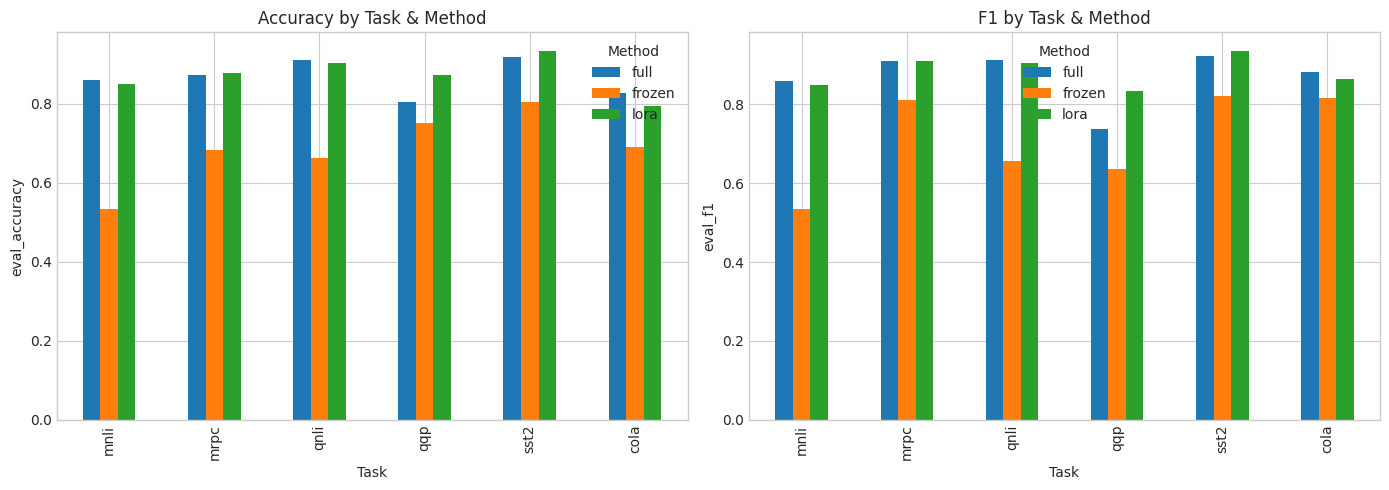

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, metric, title in [
    (axes[0], "eval_accuracy", "Accuracy by Task & Method"),
    (axes[1], "eval_f1", "F1 by Task & Method"),
]:
    pivot = df.pivot(index="task", columns="method", values=metric)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Task")
    ax.set_ylabel(metric)
    ax.legend(title="Method")

plt.tight_layout()
plt.show()

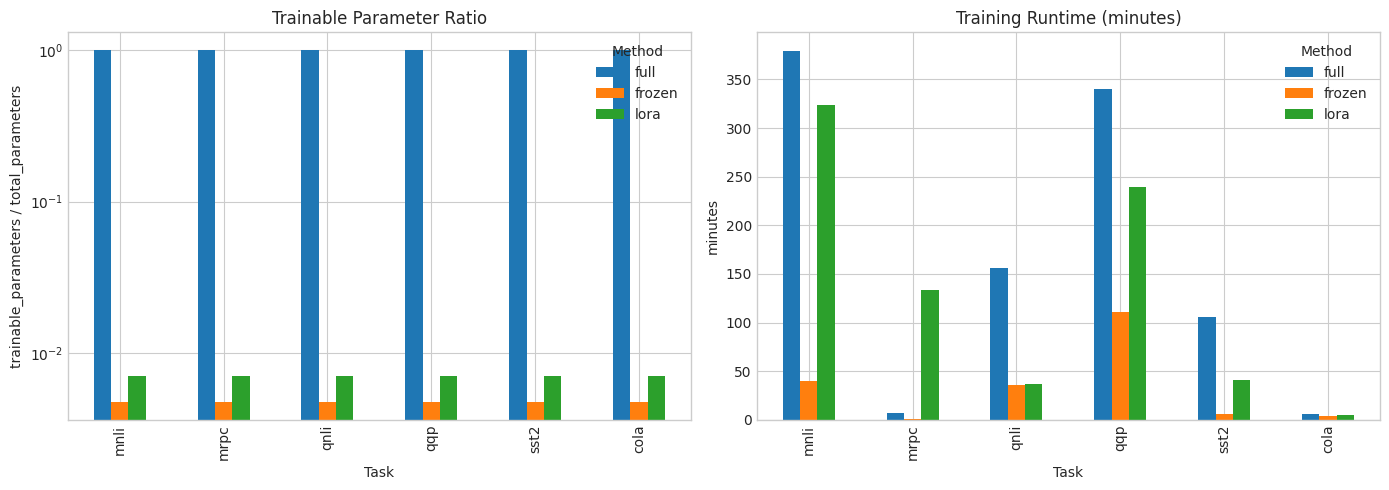

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

pivot_ratio = df.pivot(index="task", columns="method", values="trainable_ratio")
pivot_ratio.plot(kind="bar", ax=axes[0])
axes[0].set_title("Trainable Parameter Ratio")
axes[0].set_xlabel("Task")
axes[0].set_ylabel("trainable_parameters / total_parameters")
axes[0].set_yscale("log")  # full 与 frozen/lora 差距较大，用 log 更直观
axes[0].legend(title="Method")

pivot_time = df.pivot(index="task", columns="method", values="runtime_minutes")
pivot_time.plot(kind="bar", ax=axes[1])
axes[1].set_title("Training Runtime (minutes)")
axes[1].set_xlabel("Task")
axes[1].set_ylabel("minutes")
axes[1].legend(title="Method")

plt.tight_layout()
plt.show()